# YOLOv8 Food Detection Fine-tuning

YOLOv8n을 음식 데이터셋으로 fine-tune하고 ONNX로 export합니다.

**런타임 → 런타임 유형 변경 → GPU(T4)** 로 설정 후 실행하세요.

## 1. 환경 설정

In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 130.4 MB/s eta 0:00:00


In [2]:
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'CUDA available: {torch.cuda.is_available()}')

GPU: Tesla T4
CUDA available: True


## 2. 데이터셋 다운로드

Roboflow에서 YOLO 포맷 food detection 데이터셋을 받습니다.

### Option A: Roboflow API 키 사용
1. https://roboflow.com 가입 (무료)
2. Settings → API Key 복사
3. 아래 셀에서 `YOUR_API_KEY` 교체

### Option B: 직접 데이터셋 지정
Roboflow Universe에서 food detection 데이터셋을 검색하여 사용할 수 있습니다.

In [ ]:
from roboflow import Roboflow

# === Roboflow API 키를 입력하세요 ===
rf = Roboflow(api_key="YOUR_API_KEY")

# 음식 감지 데이터셋 예시 (Roboflow Universe에서 선택)
# 아래는 예시입니다. 실제 사용할 데이터셋의 workspace/project/version을 입력하세요.
# Roboflow Universe에서 'food detection'으로 검색하여 적합한 데이터셋을 찾으세요.
project = rf.workspace("anonymous-fhuzh").project("korean-food-iaryc")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to korean-food-1 in yolov8:: 100%|██████████| 15091/15091 [00:01<00:00, 8340.81it/s] 


### 데이터셋 구조 확인

In [23]:
import os

# 데이터셋 경로 확인
print(f'Dataset location: {dataset.location}')
print(f'\nFiles:')
for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files) - 5} more')

Dataset location: /content/korean-food-1

Files:
korean-food-1/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  valid/
    images/
    labels/
  train/
    images/
    labels/


## 3. YOLOv8n Fine-tune

Pre-trained YOLOv8n을 베이스로 transfer learning합니다.

In [ ]:
from ultralytics import YOLO

# YOLOv8 Nano 로드 (pre-trained on COCO)
model = YOLO('runs/detect/food_detect/yolov8n_food/weights/best.pt')

# Fine-tune
results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=50,           # 50 에포크 (Colab 무료 T4 기준 ~1-2시간)
    imgsz=640,           # 입력 크기 (현재 앱과 동일)
    batch=16,            # 배치 크기 (T4 VRAM에 맞춤)
    patience=10,         # early stopping
    device=0,            # GPU
    pretrained=True,     # transfer learning
    optimizer='AdamW',
    lr0=0.001,           # 초기 학습률
    lrf=0.01,            # 최종 학습률 비율
    project='food_detect',
    name='yolov8n_food',
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/korean-food-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/food_detect/yolov8n_food/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_food2, nbs=64, nms=False, opset=None, optimize=False, optimizer

## 4. 학습 결과 확인

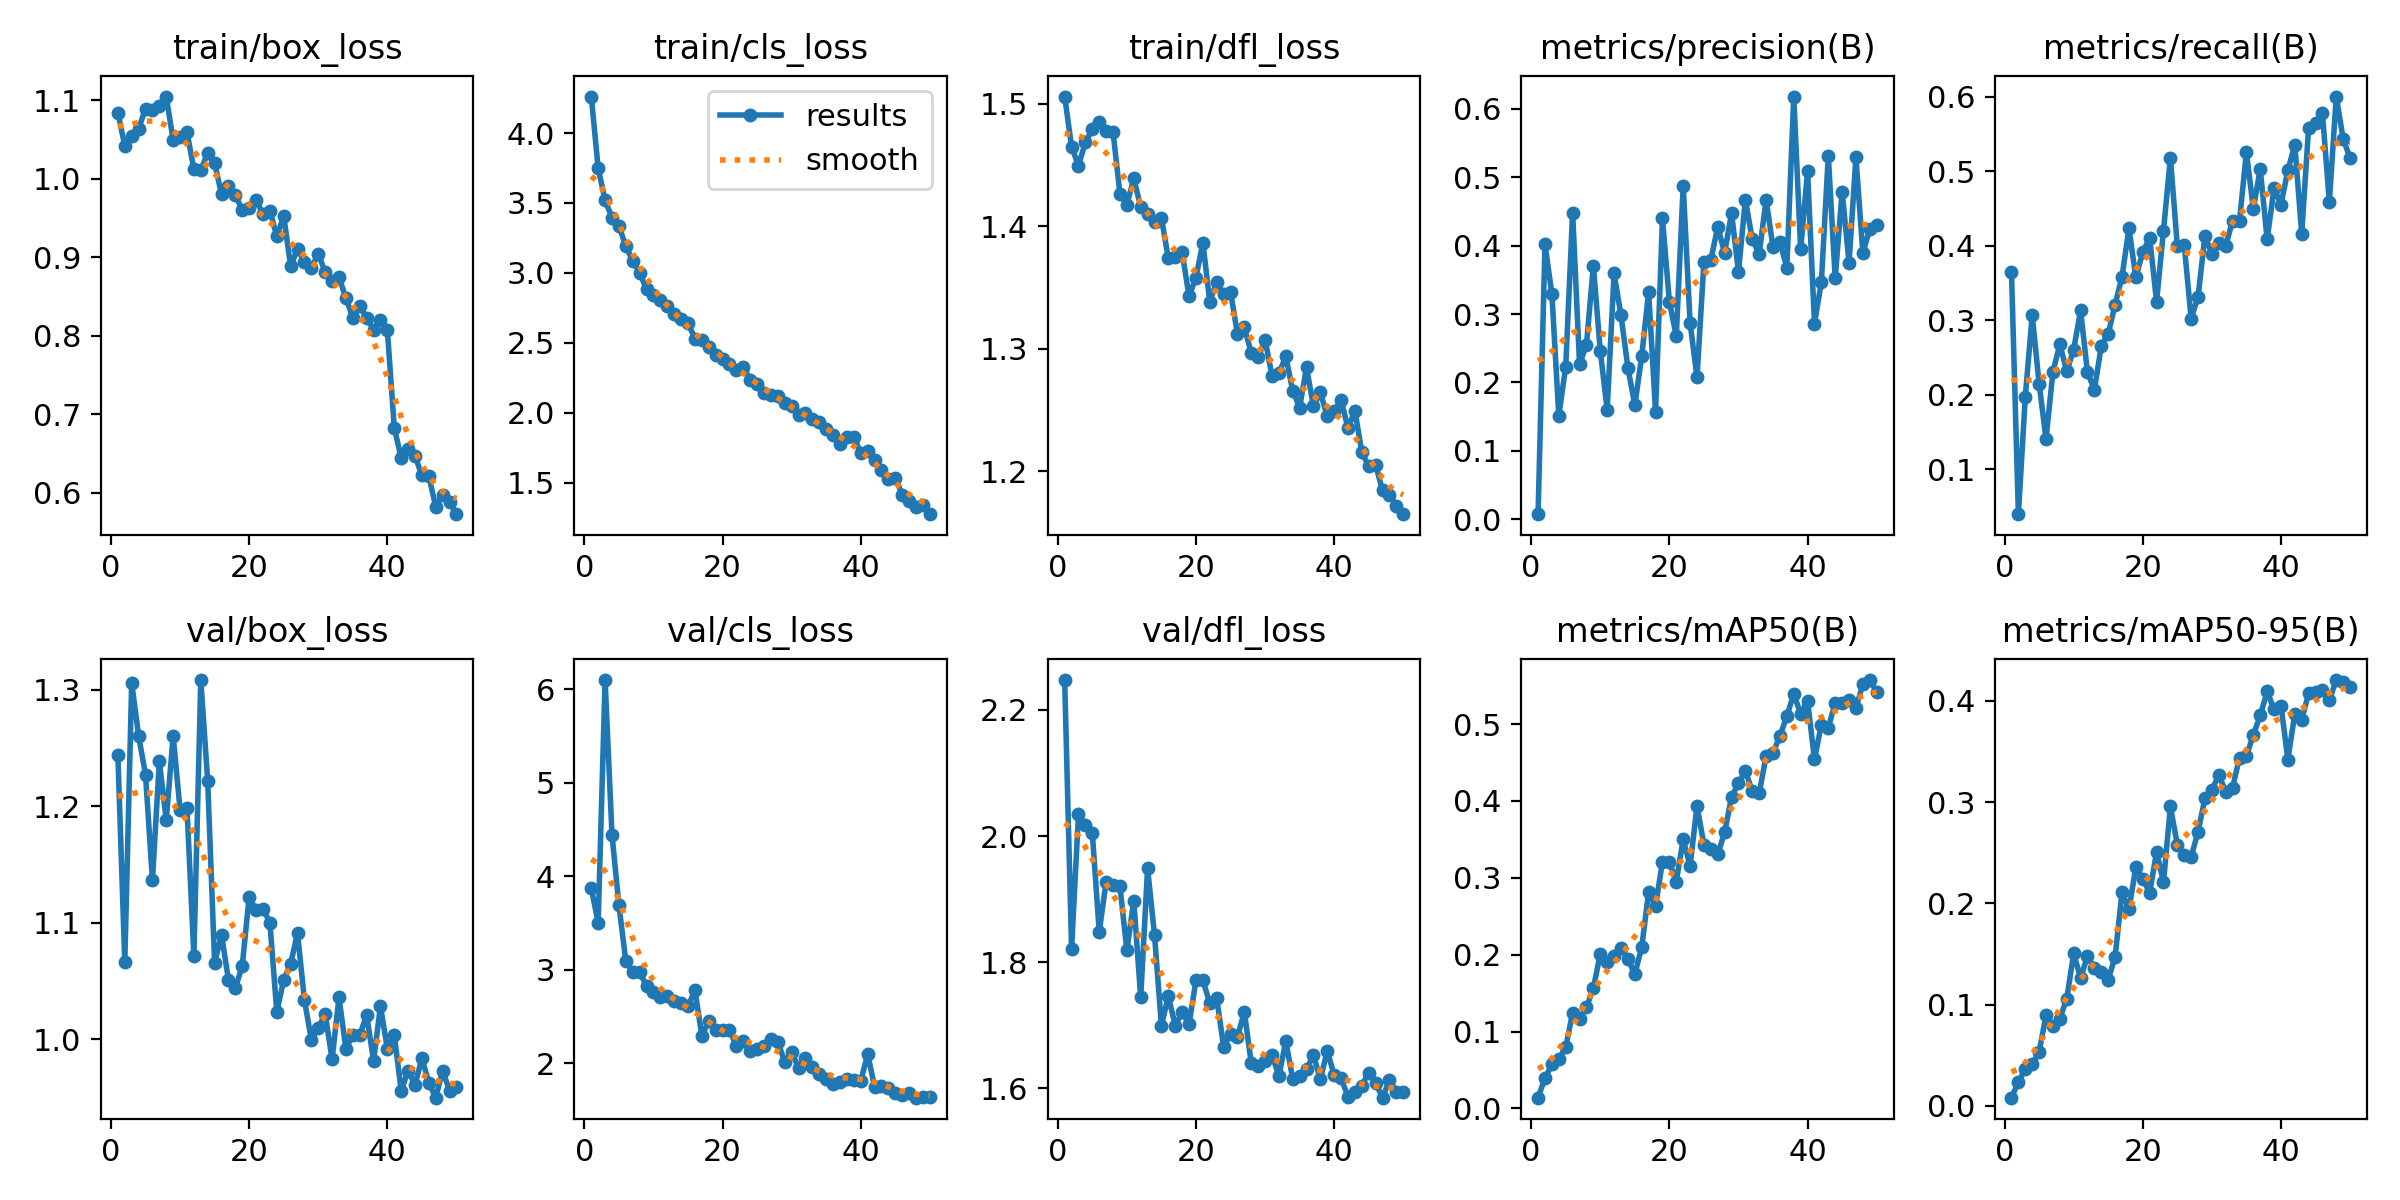

In [15]:
from IPython.display import Image, display

# 학습 곡선
display(Image(filename='runs/detect/food_detect/yolov8n_food/results.png', width=800))

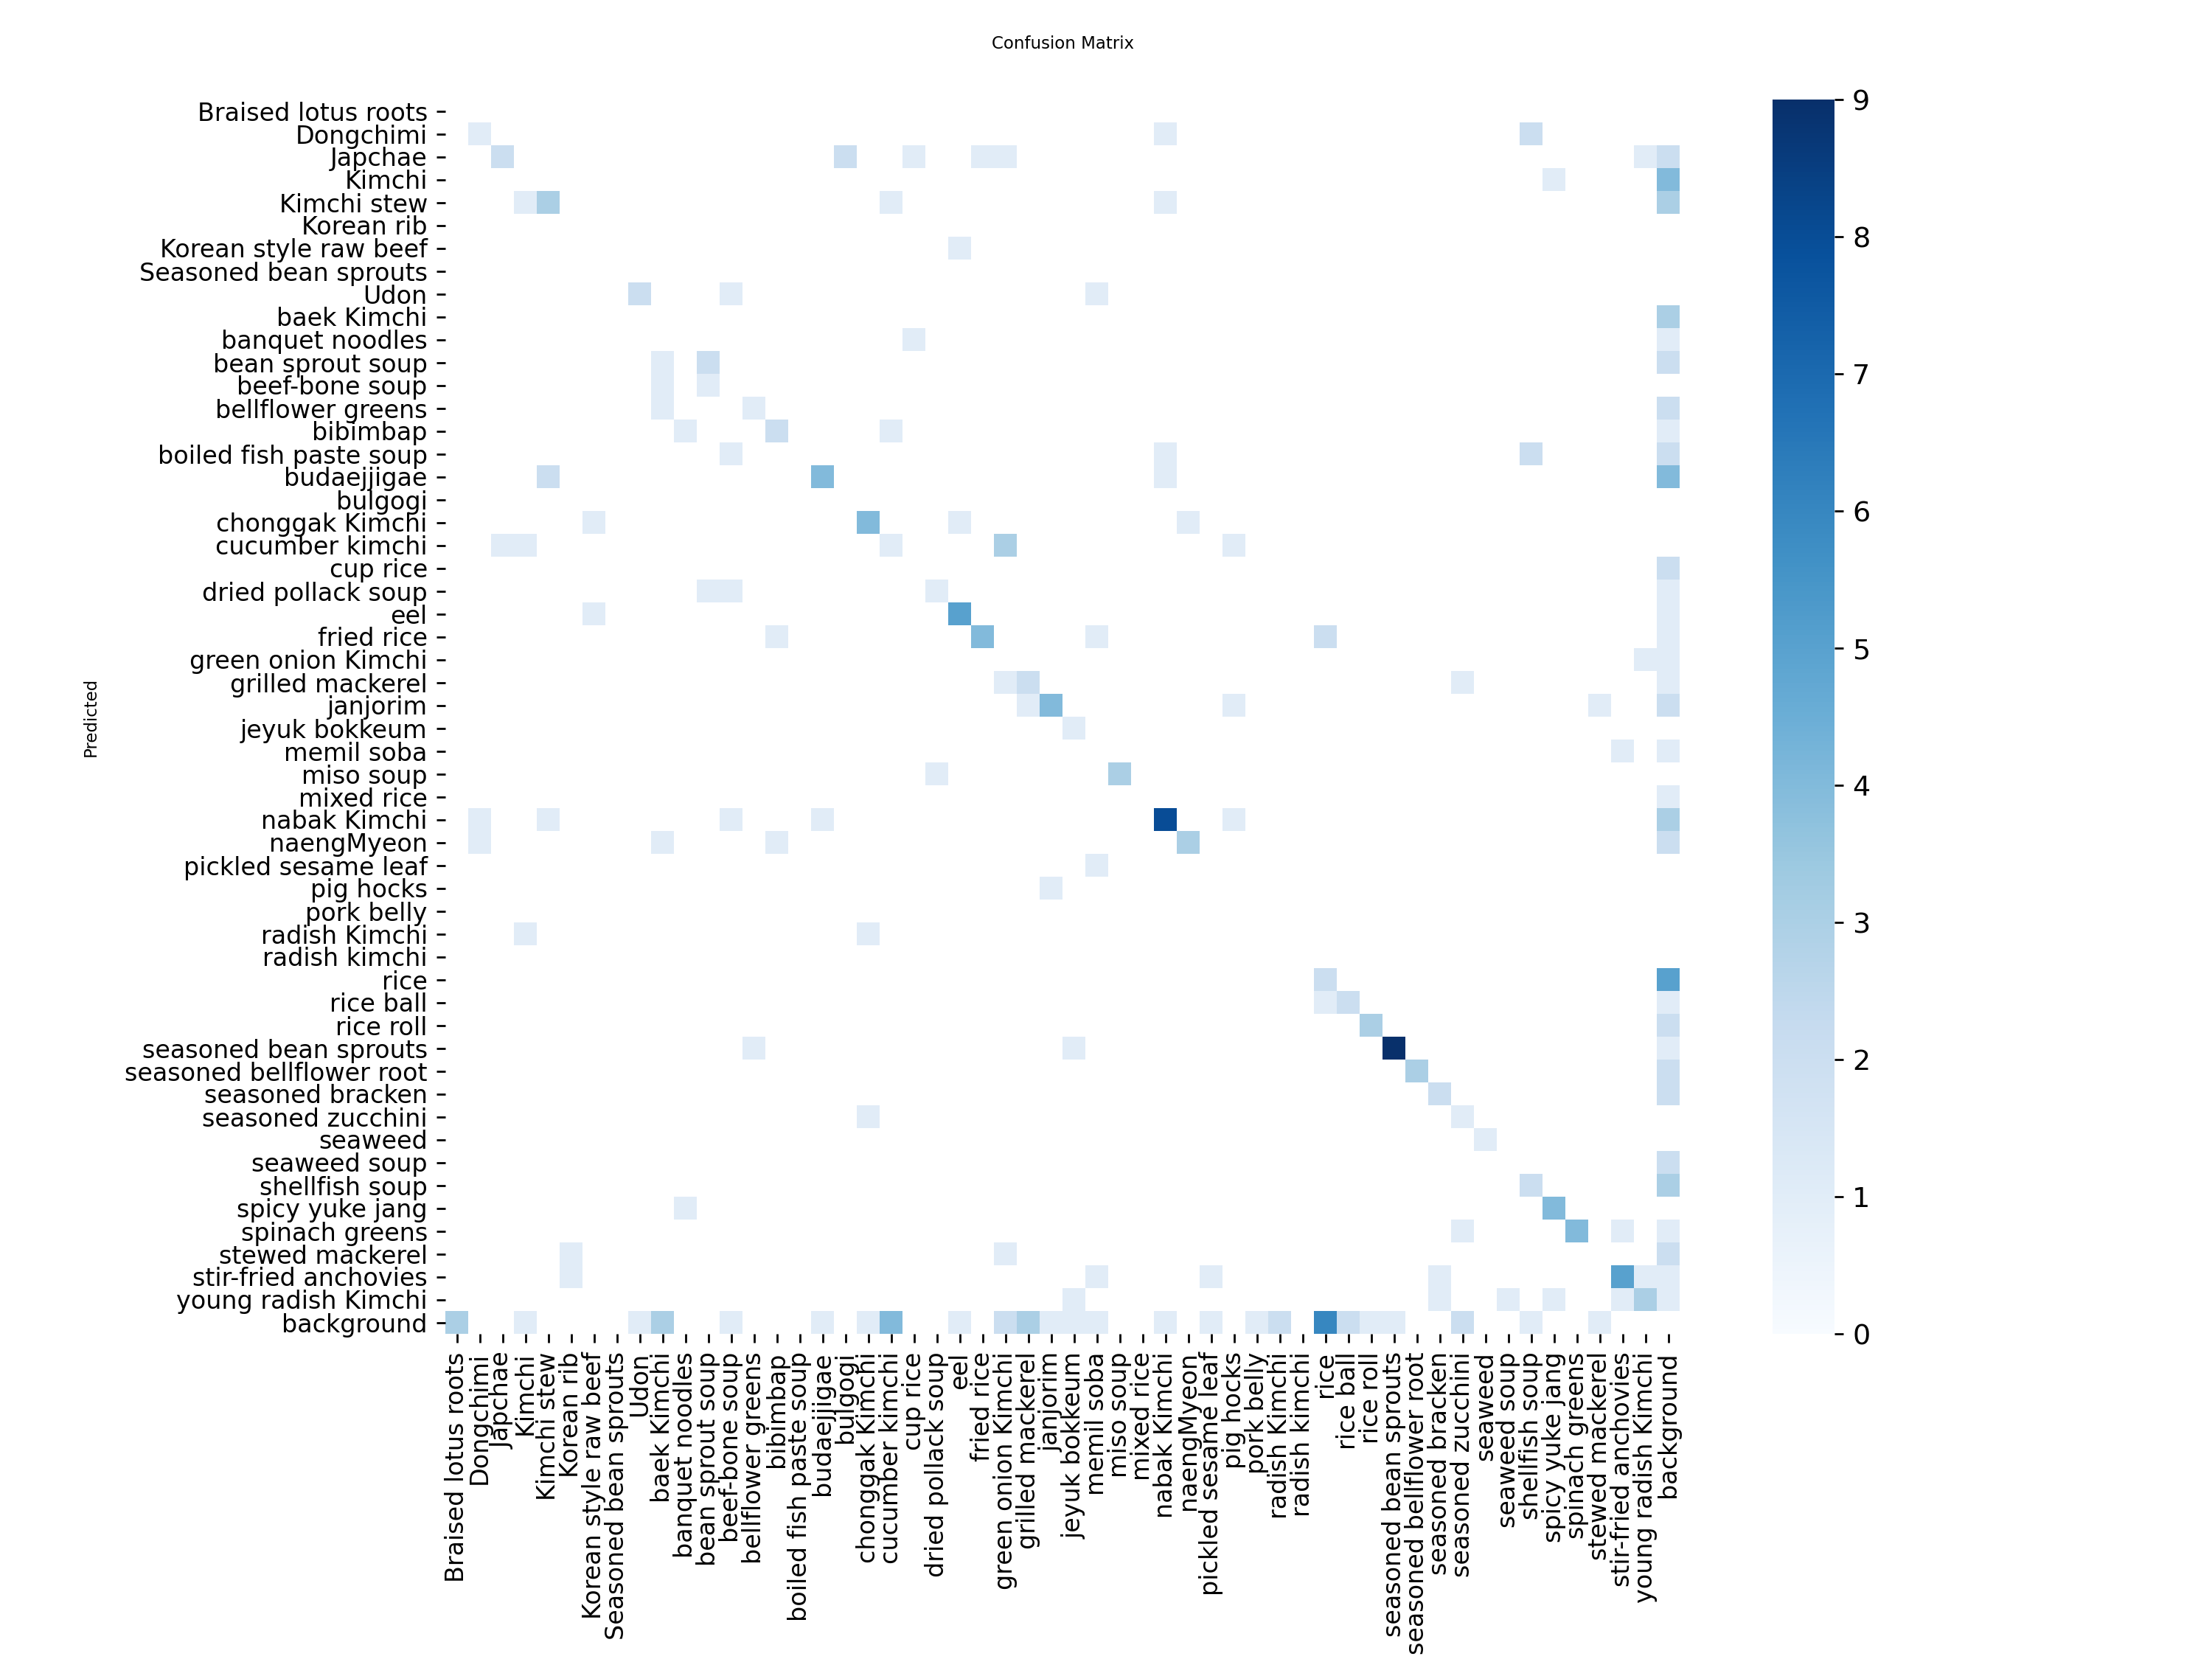

In [16]:
# Confusion matrix
display(Image(filename='runs/detect/food_detect/yolov8n_food/confusion_matrix.png', width=600))

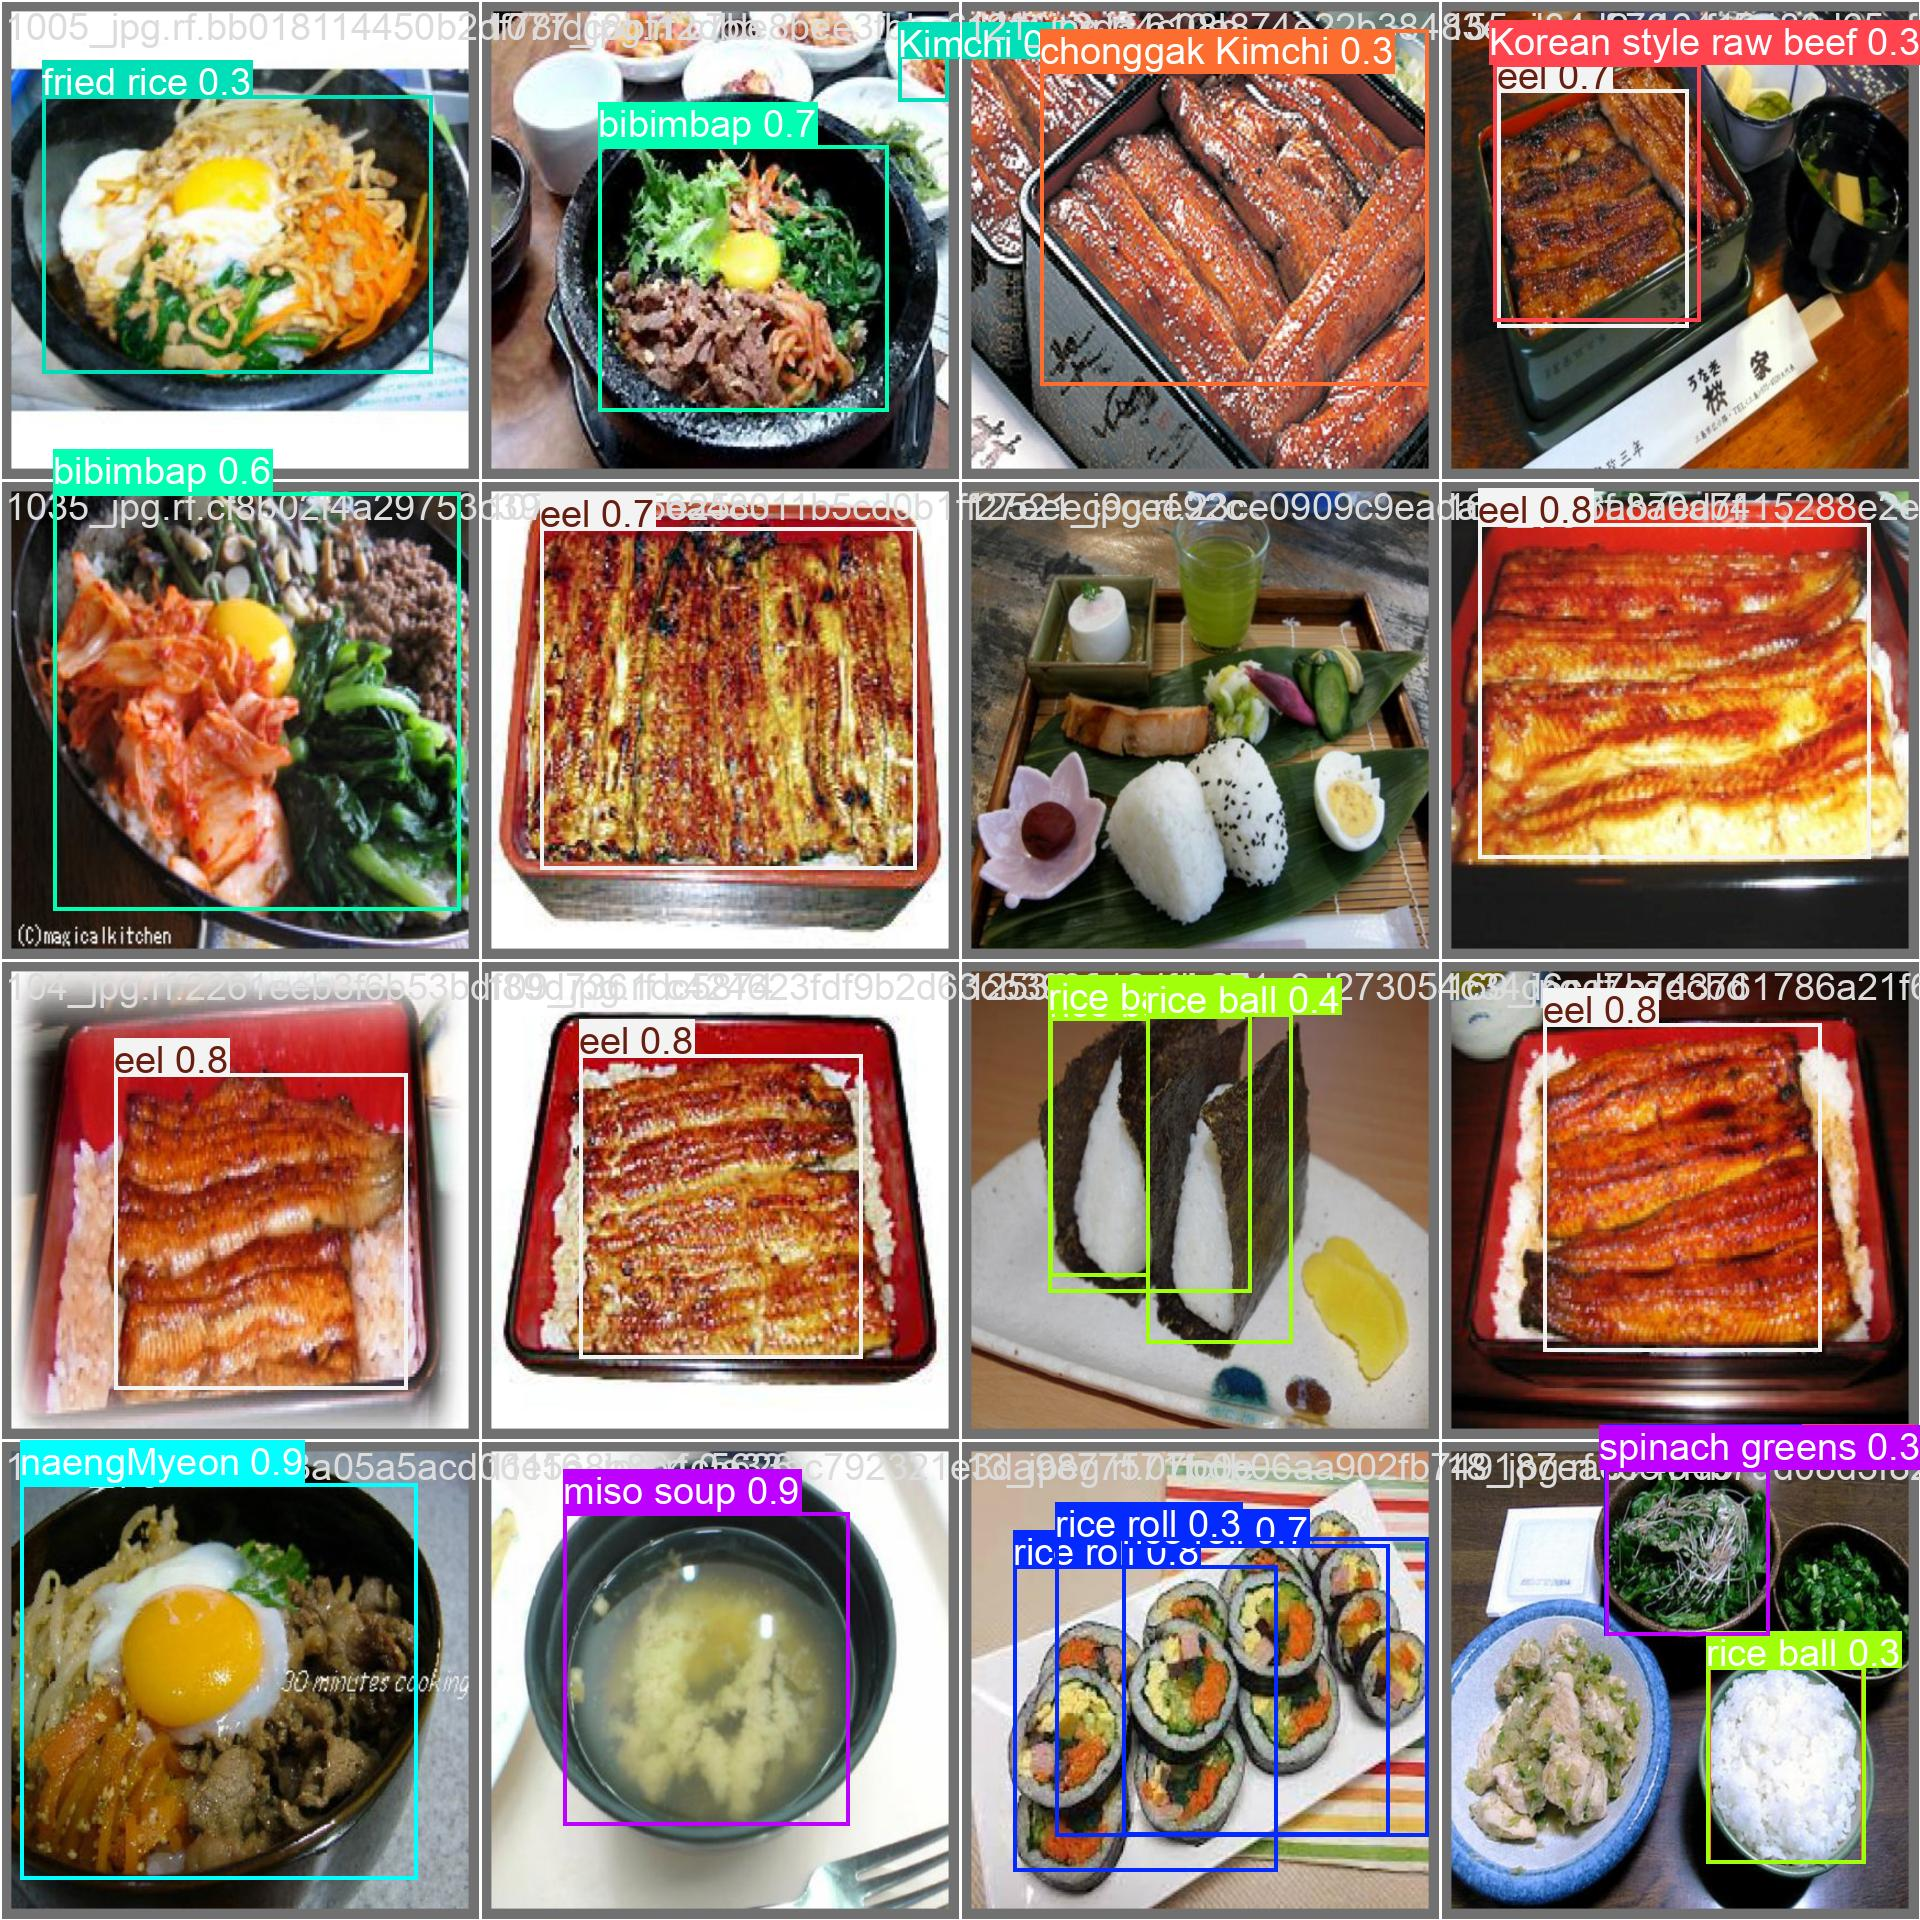

In [17]:
# Validation 샘플
display(Image(filename='runs/detect/food_detect/yolov8n_food/val_batch0_pred.jpg', width=800))

## 5. ONNX Export

앱의 onnxruntime 1.15.1과 호환되는 opset 13으로 export합니다.

In [18]:
# Best 모델 로드
best_model = YOLO('runs/detect/food_detect/yolov8n_food/weights/best.pt')

# ONNX export (opset 13, onnxruntime 1.15.1 호환)
best_model.export(
    format='onnx',
    opset=13,
    simplify=True,
)

print('\nExport 완료!')
print('파일: runs/detect/food_detect/yolov8n_food/weights/best.onnx')

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,015,983 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/food_detect/yolov8n_food/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 57, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 286ms
Prepared 4 packages in 4.15s
Installed 4 packages in 436ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 5.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 13...
O

In [19]:
# 모델 정보 확인
import onnx

m = onnx.load('runs/detect/food_detect/yolov8n_food/weights/best.onnx')
print(f'IR version: {m.ir_version}')
print(f'Opset: {m.opset_import[0].version}')
print(f'Input: {m.graph.input[0].name} {[d.dim_value or d.dim_param for d in m.graph.input[0].type.tensor_type.shape.dim]}')
print(f'Output: {m.graph.output[0].name} {[d.dim_value or d.dim_param for d in m.graph.output[0].type.tensor_type.shape.dim]}')

import os
size_mb = os.path.getsize('runs/detect/food_detect/yolov8n_food/weights/best.onnx') / 1024 / 1024
print(f'Size: {size_mb:.1f} MB')

IR version: 7
Opset: 13
Input: images [1, 3, 640, 640]
Output: output0 [1, 57, 8400]
Size: 11.7 MB


## 6. 라벨 목록 출력

앱의 `coco_labels.dart`를 교체할 라벨 맵을 생성합니다.

In [20]:
# 클래스 이름 출력 (Dart 맵 형태)
names = best_model.names
print(f'// {len(names)} classes')
print('const Map<int, String> foodLabels = {')
for idx, name in names.items():
    print(f"  {idx}: '{name}',")
print('};')

// 53 classes
const Map<int, String> foodLabels = {
  0: 'Braised lotus roots',
  1: 'Dongchimi',
  2: 'Japchae',
  3: 'Kimchi',
  4: 'Kimchi stew',
  5: 'Korean rib',
  6: 'Korean style raw beef',
  7: 'Seasoned bean sprouts',
  8: 'Udon',
  9: 'baek Kimchi',
  10: 'banquet noodles',
  11: 'bean sprout soup',
  12: 'beef-bone soup',
  13: 'bellflower greens',
  14: 'bibimbap',
  15: 'boiled fish paste soup',
  16: 'budaejjigae',
  17: 'bulgogi',
  18: 'chonggak Kimchi',
  19: 'cucumber kimchi',
  20: 'cup rice',
  21: 'dried pollack soup',
  22: 'eel',
  23: 'fried rice',
  24: 'green onion Kimchi',
  25: 'grilled mackerel',
  26: 'janjorim',
  27: 'jeyuk bokkeum',
  28: 'memil soba',
  29: 'miso soup',
  30: 'mixed rice',
  31: 'nabak Kimchi',
  32: 'naengMyeon',
  33: 'pickled sesame leaf',
  34: 'pig hocks',
  35: 'pork belly',
  36: 'radish Kimchi',
  37: 'radish kimchi',
  38: 'rice',
  39: 'rice ball',
  40: 'rice roll',
  41: 'seasoned bean sprouts',
  42: 'seasoned bellflower 

## 7. 다운로드

학습된 모델을 다운로드합니다.

In [21]:
from google.colab import files

# ONNX 모델 다운로드
files.download('runs/detect/food_detect/yolov8n_food/weights/best.onnx')

# PT 모델도 백업 (추후 재학습용)
files.download('runs/detect/food_detect/yolov8n_food/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 다음 단계

1. 다운로드한 `best.onnx`를 `assets/models/yolov8n.onnx`로 교체
2. 위에서 출력된 라벨 맵으로 `lib/models/coco_labels.dart` 교체
3. `InferencePipeline`의 `_numClasses`를 새 클래스 수로 변경
4. `flutter run`으로 테스트

### 한식 데이터 보강 시
1. 한식 이미지 수집 + Roboflow에서 라벨링
2. 기존 데이터셋과 병합
3. 이 노트북의 `best.pt`를 베이스로 추가 학습 (transfer learning 2단계)